In [11]:
import pandas as pd
import numpy as np

# Load dataset

filename = 'airfoil_dataset.tsv'
dataset = np.loadtxt(filename, delimiter='\t',skiprows=0)  

print(type(dataset))
print(np.shape(dataset))
print(dataset[0:5])

X = dataset[:, 0:5]   # Independent features
y = dataset[:, -1]    # Target

<class 'numpy.ndarray'>
(1503, 6)
[[8.00000e+02 0.00000e+00
  3.04800e-01 7.13000e+01
  2.66337e-03 1.26201e+02]
 [1.00000e+03 0.00000e+00
  3.04800e-01 7.13000e+01
  2.66337e-03 1.25201e+02]
 [1.25000e+03 0.00000e+00
  3.04800e-01 7.13000e+01
  2.66337e-03 1.25951e+02]
 [1.60000e+03 0.00000e+00
  3.04800e-01 7.13000e+01
  2.66337e-03 1.27591e+02]
 [2.00000e+03 0.00000e+00
  3.04800e-01 7.13000e+01
  2.66337e-03 1.27461e+02]]


In [12]:
np.shape(X[0])

(5,)

In [3]:
# Split data in training - testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

1007
496
1007
496


In [4]:
# Train model
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X_train, y_train)

In [5]:
# Extract predictions on testing data
preds = model.predict(X_test)
print(len(preds))
print(preds[0:5])

496
[124.06768512 119.59316737
 120.29933092 129.61912851
 129.81089779]


In [6]:
# Compute error metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mse = mean_squared_error(y_test, preds)
print(mse)

22.954669535134155


In [7]:
# Try regularization (Ridge)
from sklearn.linear_model import Ridge

for alpha in [0.00001, 0.001, 0.1, 0.25, 0.5, 1, 5, 10, 100]:
    print(alpha)
    ridge_reg = Ridge(alpha, solver="cholesky", random_state=42)
    ridge_reg.fit(X_train, y_train)
    preds = ridge_reg.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    print(mse)
    print()

1e-05
22.954639326926085

0.001
22.952089824401884

0.1
23.48077458486391

0.25
23.93230606938778

0.5
24.260276432711176

1
24.627617881773013

5
26.821990773111366

10
28.756120399738194

100
34.05285542379348



In [8]:
# Try regularization (Lasso)
from sklearn.linear_model import Lasso

for alpha in [0.00001, 0.001, 0.1, 0.25, 0.5, 1, 5, 10, 100]:
    print(alpha)
    lasso_reg = Lasso(alpha, random_state=42)
    lasso_reg.fit(X_train, y_train)
    preds = lasso_reg.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    print(mse)
    print()

1e-05
22.95451444341896

0.001
22.95662458923143

0.1
26.573212597159024

0.25
35.254858302330405

0.5
35.3426024578323

1
35.46968520448818

5
37.21443627899279

10
41.103709603038375

100
42.187489843237195



In [9]:
# Try regularization (ElasticNet)
from sklearn.linear_model import ElasticNet

for alpha in [0.0000001, 0.000001, 0.00001, 0.001, 0.1, 0.25, 0.5, 1, 5, 10, 100]:
    print(alpha)
    elastic_reg = ElasticNet(alpha, random_state=42)
    elastic_reg.fit(X_train, y_train)
    preds = elastic_reg.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    print(mse)
    print()

1e-07
22.954517597348914

1e-06
22.953254435081156

1e-05
22.949579267920292

0.001
24.285377320613055

0.1
33.49962720255488

0.25
34.7845825430875

0.5
35.303252890587835

1
35.377895592803526

5
36.194707079918444

10
37.62421816195245

100
42.19586968032121



In [10]:
# 1e-05
# 22.949579267920303

# Best result!

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.mean(axis=0).round(4))
print(X_train_scaled.std(axis=0).round(4))

[-0.  0. -0.  0.  0.]
[1. 1. 1. 1. 1.]


In [ ]:
from sklearn.model_selection import GridSearchCV

# Store results
results = {}

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
results['Linear Regression'] = mean_squared_error(y_test, lr.predict(X_test_scaled))

# Ridge
ridge = Ridge()
ridge_params = {'alpha': [0.00001, 0.001, 0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(ridge, ridge_params, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train_scaled, y_train)
results['Ridge'] = mean_squared_error(y_test, ridge_grid.predict(X_test_scaled))

# Lasso
lasso = Lasso(max_iter=10000)
lasso_params = {'alpha': [0.00001, 0.001, 0.1, 1, 10, 100]}
lasso_grid = GridSearchCV(lasso, lasso_params, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train_scaled, y_train)
results['Lasso'] = mean_squared_error(y_test, lasso_grid.predict(X_test_scaled))

# ElasticNet
elastic = ElasticNet(max_iter=10000)
elastic_params = {'alpha': [0.00001, 0.001, 0.1, 1, 10], 'l1_ratio': [0.1, 0.5, 0.9]}
elastic_grid = GridSearchCV(elastic, elastic_params, cv=5, scoring='neg_mean_squared_error')
elastic_grid.fit(X_train_scaled, y_train)
results['ElasticNet'] = mean_squared_error(y_test, elastic_grid.predict(X_test_scaled))

# Print 
print("\nModel Comparison (MSE):")
for model, mse in results.items():
    print(f"{model}: {mse:.4f}")
print(f"\nBest model: {min(results, key=results.get)}")


Model Comparison (MSE):
Linear Regression: 22.9547
Ridge: 22.9599
Lasso: 22.9547
ElasticNet: 22.9596

Best model: Linear Regression


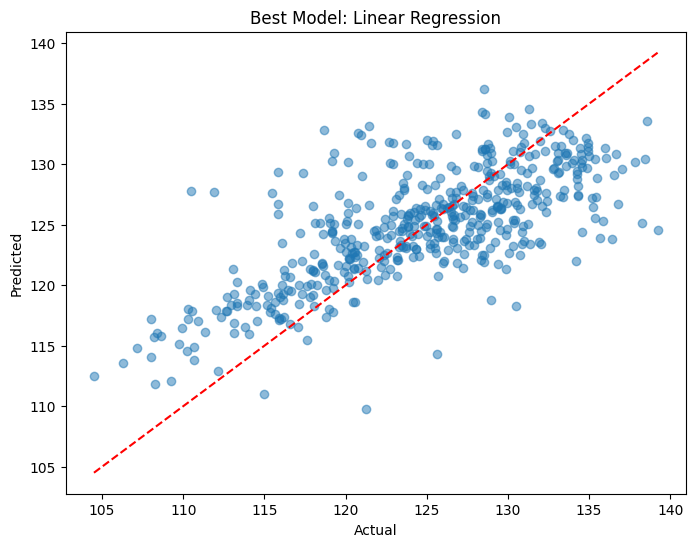

In [16]:
import matplotlib.pyplot as plt

if min(results, key=results.get) == 'Ridge':
    best_preds = ridge_grid.predict(X_test_scaled)
elif min(results, key=results.get) == 'Lasso':
    best_preds = lasso_grid.predict(X_test_scaled)
elif min(results, key=results.get) == 'ElasticNet':
    best_preds = elastic_grid.predict(X_test_scaled)
else:
    best_preds = lr.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Best Model: {min(results, key=results.get)}')
plt.show()